# NFL Salary Cap Allocation & Team Performance

**Question:** Every NFL team has the same salary budget (the cap). Does how a team divides that budget across positions, and whether it pays one star or spreads money across a group, relate to how well it performs?

This notebook runs top to bottom. See `PRD.md` for the full spec and `README.md` for the write-up.

## §0 Setup and constants

We load the libraries and set up a few values that every later section uses: the seasons we study, the league salary cap for each year, and a fix for teams that moved cities.

*Summary:* No data is touched yet. We're just writing down the fixed facts in one place, so if one is wrong we only have to change it here.

In [1]:
import os
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Git does not store empty folders, so create them here for a fresh clone
for folder in ["data/raw", "data/processed", "charts"]:
    os.makedirs(folder, exist_ok=True)

# range() stops before the end number, so 2026 means "through 2025"
SEASONS = list(range(2013, 2026))

# League salary cap per season, in millions of dollars (source: NFL / OverTheCap).
# Hardcoded because it is only 13 numbers, and they never change once a season is set.
# Note the 2021 drop: the cap shrank because of COVID revenue losses.
LEAGUE_CAP = {
    2013: 123.0, 2014: 133.0, 2015: 143.28, 2016: 155.27, 2017: 167.0,
    2018: 177.2, 2019: 188.2, 2020: 198.2, 2021: 182.5, 2022: 208.2,
    2023: 224.8, 2024: 255.4, 2025: 279.2,
}

# Three teams moved cities during our window. We always use the team's CURRENT
# abbreviation, so a franchise stays one team across all 13 seasons.
TEAM_FIX = {
    "OAK": "LV",   # Oakland Raiders -> Las Vegas (2020)
    "SD": "LAC",   # San Diego Chargers -> Los Angeles (2017)
    "STL": "LA",   # St. Louis Rams -> Los Angeles (2016)
}


def standardize_team(abbreviation):
    """Return the current abbreviation for a team (unchanged if it never moved)."""
    return TEAM_FIX.get(abbreviation, abbreviation)

## §1 Results: point differential per game

We download every game from 2013–2025, keep only regular-season games, and turn each game into two rows: one for the home team and one for the away team. Then we add up each team's season.

*Summary:* The output is one row per team per season with wins, points scored and points allowed. Our main outcome is **point differential per game** (points scored minus points allowed, divided by games). We divide by games because the season grew from 16 to 17 games in 2021.

In [2]:
# nflreadpy returns a Polars table, so convert to pandas right away
schedules = nfl.load_schedules(SEASONS).to_pandas()

# Save an untouched copy so we can see exactly what we downloaded
schedules.to_csv("data/raw/schedules.csv", index=False)

# Keep regular season only (playoffs would reward good teams with extra games)
reg_season = schedules[schedules["game_type"] == "REG"]

# Drop games with no score. The 2022 Bills-Bengals game was cancelled,
# so both of those teams played 16 games instead of 17 that year.
reg_season = reg_season.dropna(subset=["home_score", "away_score"])

print("Regular-season games:", len(reg_season))

Regular-season games: 3407


In [3]:
# Each game has a home team and an away team. We want one row per TEAM per game,
# so we build a home-team view and an away-team view, then stack them.
home_games = pd.DataFrame({
    "season": reg_season["season"],
    "team": reg_season["home_team"],
    "points_for": reg_season["home_score"],
    "points_against": reg_season["away_score"],
})
away_games = pd.DataFrame({
    "season": reg_season["season"],
    "team": reg_season["away_team"],
    "points_for": reg_season["away_score"],
    "points_against": reg_season["home_score"],
})
team_games = pd.concat([home_games, away_games], ignore_index=True)

# Relocated teams get their current abbreviation
team_games["team"] = team_games["team"].apply(standardize_team)

# Win = 1, tie = 0.5, loss = 0 (the standard way NFL win % counts ties)
team_games["win"] = 0.0
team_games.loc[team_games["points_for"] > team_games["points_against"], "win"] = 1.0
team_games.loc[team_games["points_for"] == team_games["points_against"], "win"] = 0.5

team_games.head()

,season,team,points_for,points_against,win
0,2013,DEN,49,27,1.0
1,2013,BUF,21,23,0.0
2,2013,CAR,7,12,0.0
3,2013,CHI,24,21,1.0
4,2013,CLE,10,23,0.0


In [4]:
# Add up each team's season
results = team_games.groupby(["team", "season"]).agg(
    games=("win", "count"),
    wins=("win", "sum"),
    points_for=("points_for", "sum"),
    points_against=("points_against", "sum"),
).reset_index()

# Per-game versions, so 16- and 17-game seasons are comparable
results["win_pct"] = results["wins"] / results["games"]
results["pf_per_game"] = results["points_for"] / results["games"]
results["pa_per_game"] = results["points_against"] / results["games"]
results["point_diff_per_game"] = results["pf_per_game"] - results["pa_per_game"]

# Checks: if any of these fail, something upstream is wrong
assert len(results) == 32 * 13, f"Expected 416 team-seasons, got {len(results)}"
assert results["team"].nunique() == 32, "Relocated teams were not merged"
assert results["games"].isin([16, 17]).all(), "A team-season has an odd number of games"

results.describe().round(2)

,season,games,wins,points_for,points_against,win_pct,pf_per_game,pa_per_game,point_diff_per_game
count,416.00,416.00,416.00,416.00,416.00,416.00,416.00,416.00,416.00
mean,2019.00,16.38,8.19,373.85,373.85,0.50,22.83,22.83,0.00
std,3.75,0.49,3.14,69.96,55.77,0.19,4.27,3.40,6.07
min,2013.00,16.00,0.00,224.00,225.00,0.00,13.88,14.06,-13.38
25%,2016.00,16.00,6.00,322.75,332.00,0.38,19.86,20.34,-4.50
50%,2019.00,16.00,8.00,369.00,372.50,0.50,22.56,22.59,-0.24
75%,2022.00,17.00,11.00,420.00,413.00,0.65,25.96,25.06,4.51
max,2025.00,17.00,15.00,606.00,534.00,0.94,37.88,32.44,15.56


In [5]:
# Sanity check against a known season: the 2023 Chiefs scored 371 and allowed 294
# in 17 games, so point differential per game should be (371 - 294) / 17 = 4.53
results[(results["team"] == "KC") & (results["season"] == 2023)]

,team,season,games,wins,points_for,points_against,win_pct,pf_per_game,pa_per_game,point_diff_per_game
205,KC,2023,17,11.0,371,294,0.647059,21.823529,17.294118,4.529412


## §2 Salary data: one row per player per season

The nflverse contracts data (collected by OverTheCap) has one row per **contract**. Each contract holds a list of that player's seasons with his **cap hit**, the amount that counts against the team's salary cap that year. We unpack those lists into one flat table.

Three things need care:
1. **The same seasons repeat across contracts.** A player with 3 contracts has his history repeated 3 times, so we must keep only one row per player per season.
2. **Players change positions.** For each season we use the position on the contract that was in effect *that* season, meaning the most recent one signed on or before that year. Seasons with no such contract are dropped. That's about 6% of player-seasons, but only about 1% of salary dollars, because they're mostly small deals.
3. **Teams are nicknames** ("Bengals"), so we translate them to the abbreviations used in §1. Washington is always the Commanders.

*Summary:* The output is `player_seasons`: one row per player per season with his team, position and cap hit. We then check that each team's total lands near the league cap. Totals come in lower than the cap because we leave out dead money, which is cap charges for players no longer on the team.

In [6]:
contracts_polars = nfl.load_contracts()

# Save an untouched copy. Parquet (not CSV) because the season lists are nested data.
contracts_polars.write_parquet("data/raw/contracts.parquet")

contracts = contracts_polars.to_pandas()
print("Contracts:", len(contracts), " Players:", contracts["otc_id"].nunique())

Contracts: 52959  Players: 12886


In [7]:
# Each contract row holds a list of seasons in "season_history".
# Unpack it into a flat table: one row per contract per season.
season_rows = []
for _, contract in contracts.iterrows():
    history = contract["season_history"]
    if history is None:  # a few contracts have no season detail
        continue
    for season_entry in history:
        season_rows.append({
            "otc_id": contract["otc_id"],  # OverTheCap's player ID
            "player": contract["player"],
            "position": contract["position"],
            "year_signed": contract["year_signed"],
            "season": season_entry["year"],
            "team_name": season_entry["team"],
            "cap_hit": season_entry["cap_number"],  # millions of dollars
        })
contract_seasons = pd.DataFrame(season_rows)

# The lists end with a "Total" row, and some entries have no year or no team
contract_seasons = contract_seasons[contract_seasons["season"].notna()]
contract_seasons = contract_seasons[contract_seasons["season"] != "Total"]
contract_seasons = contract_seasons[contract_seasons["team_name"] != ""]
contract_seasons["season"] = contract_seasons["season"].astype(int)
contract_seasons = contract_seasons[contract_seasons["season"].isin(SEASONS)]

print("Rows before removing repeats:", len(contract_seasons))

Rows before removing repeats: 216783


In [8]:
# Keep only contracts that were already signed by that season...
contract_seasons = contract_seasons[contract_seasons["year_signed"] <= contract_seasons["season"]]

# ...then, for each player-season, keep the most recently signed one.
# Sorting by year_signed puts the newest contract last, and keep="last" keeps it.
contract_seasons = contract_seasons.sort_values("year_signed")
player_seasons = contract_seasons.drop_duplicates(subset=["otc_id", "season"], keep="last")

print("Player-seasons:", len(player_seasons))

Player-seasons: 30368


In [9]:
# Translate team nicknames into the abbreviations used in the results table
NICKNAME_TO_TEAM = {
    "49ers": "SF", "Bears": "CHI", "Bengals": "CIN", "Bills": "BUF",
    "Broncos": "DEN", "Browns": "CLE", "Buccaneers": "TB", "Cardinals": "ARI",
    "Chargers": "LAC", "Chiefs": "KC", "Colts": "IND", "Cowboys": "DAL",
    "Dolphins": "MIA", "Eagles": "PHI", "Falcons": "ATL", "Giants": "NYG",
    "Jaguars": "JAX", "Jets": "NYJ", "Lions": "DET", "Packers": "GB",
    "Panthers": "CAR", "Patriots": "NE", "Raiders": "LV", "Rams": "LA",
    "Ravens": "BAL", "Saints": "NO", "Seahawks": "SEA", "Steelers": "PIT",
    "Texans": "HOU", "Titans": "TEN", "Vikings": "MIN",
    # Washington is always treated as the Commanders, whatever the name was that year
    "Commanders": "WAS", "Washington": "WAS", "Redskins": "WAS",
}
player_seasons["team"] = player_seasons["team_name"].map(NICKNAME_TO_TEAM)

# Any nickname missing from the dictionary would show up as a blank team
unmapped = player_seasons[player_seasons["team"].isna()]["team_name"].unique()
assert len(unmapped) == 0, f"Nicknames missing from the map: {unmapped}"

# Every team-season in the results table should have salary data, and vice versa
salary_team_seasons = player_seasons[["team", "season"]].drop_duplicates()
check = results[["team", "season"]].merge(salary_team_seasons, how="outer", indicator=True)
print(check["_merge"].value_counts())
assert (check["_merge"] == "both").all(), "Some team-seasons appear in only one table"

_merge
both          416
left_only       0
right_only      0
Name: count, dtype: int64


In [10]:
# How close does each team's total come to the league cap?
team_totals = player_seasons.groupby(["team", "season"])["cap_hit"].sum().reset_index()
team_totals["pct_of_cap"] = team_totals["cap_hit"] / team_totals["season"].map(LEAGUE_CAP)

print(team_totals["pct_of_cap"].describe().round(2))

# The lowest ones are seasons with lots of dead money (cut or traded players still
# counting against the cap), which we leave out on purpose. Spending shares divide
# by the team's own total, so this does not distort them.
team_totals.sort_values("pct_of_cap").head(5).round(2)

count    416.00
mean       0.84
std        0.09
min        0.48
25%        0.79
50%        0.86
75%        0.91
max        1.09
Name: pct_of_cap, dtype: float64


,team,season,cap_hit,pct_of_cap
234,LV,2013,58.99,0.48
74,CHI,2022,112.26,0.54
324,NYJ,2025,157.10,0.56
22,ATL,2022,118.84,0.57
253,MIA,2019,110.56,0.59


In [11]:
player_seasons = player_seasons[["team", "season", "otc_id", "player", "position", "cap_hit"]]
player_seasons.to_csv("data/processed/player_seasons.csv", index=False)
player_seasons.head()

,team,season,otc_id,player,position,cap_hit
191775,NYG,2014,2495,Paul Hazel,IDL,0.116471
304966,BAL,2013,2885,Omar Brown,S,0.254118
304974,DET,2014,2931,Nate Ness,S,0.094500
304976,ARI,2013,337,Curtis Taylor,S,0.097941
304980,GB,2013,1125,M.D. Jennings,S,0.555834


## §3 Build the team-season table

This is the table the whole analysis runs on: one row per team per season, with three kinds of columns.

1. **Spending share** per position group: the share of the team's player salary that goes to that group. The shares add up to 100% for every team.
2. **Concentration** for groups where several players start (WR/TE, OL, DL/EDGE, LB, CB): the highest-paid player's share of his group's money. A value near 1 means one star takes almost all of it. A value near 0 means the money is spread out.
3. **Rookie QB flag**: 1 if the team's main starting QB was drafted and in his first 4 seasons. Rookie deals are cheap, which frees money for everyone else.

*Summary:* We group player cap hits by team, season and position group, then turn the sums into shares. Separately, we find each team's main QB and check how long ago he was drafted. Then we join everything onto the results table from §1.

In [12]:
# Map each contract position to one of our 9 groups. Short lowercase names,
# because these become column names and statsmodels formulas can't handle "/".
POSITION_GROUPS = {
    "QB": "qb",
    "RB": "rb", "FB": "rb",
    "WR": "wr_te", "TE": "wr_te",
    "LT": "ol", "LG": "ol", "C": "ol", "RG": "ol", "RT": "ol",
    "IDL": "dl_edge", "ED": "dl_edge",
    "LB": "lb",
    "CB": "cb",
    "S": "s",
    "K": "st", "P": "st", "LS": "st",  # special teams: kicker, punter, long snapper
}
player_seasons["group"] = player_seasons["position"].map(POSITION_GROUPS)
assert player_seasons["group"].notna().all(), "A position is missing from POSITION_GROUPS"

# For each team, season and group: total money, and the single biggest cap hit
group_cap = player_seasons.groupby(["team", "season", "group"])["cap_hit"].agg(["sum", "max"]).reset_index()
group_cap = group_cap.rename(columns={"sum": "group_cap_hit", "max": "top_player_cap_hit"})

# Bring in each team's total (from §2) so we can turn dollars into shares
team_cap = team_totals[["team", "season", "cap_hit"]].rename(columns={"cap_hit": "team_cap_hit"})
group_cap = group_cap.merge(team_cap, on=["team", "season"], how="left")

group_cap["share"] = group_cap["group_cap_hit"] / group_cap["team_cap_hit"]
group_cap["top_share"] = group_cap["top_player_cap_hit"] / group_cap["group_cap_hit"]
group_cap.head()

,team,season,group,group_cap_hit,top_player_cap_hit,team_cap_hit,share,top_share
0,ARI,2013,cb,9.034783,5.026227,92.520621,0.097652,0.556320
1,ARI,2013,dl_edge,25.290625,8.750000,92.520621,0.273351,0.345978
2,ARI,2013,lb,6.664030,2.854044,92.520621,0.072028,0.428276
3,ARI,2013,ol,16.691690,7.275000,92.520621,0.180410,0.435846
4,ARI,2013,qb,6.172993,4.000000,92.520621,0.066720,0.647984


In [13]:
# Spending shares: reshape so each group becomes its own column (qb_share, rb_share, ...)
shares = group_cap.pivot_table(index=["team", "season"], columns="group", values="share", fill_value=0)
shares.columns = [group + "_share" for group in shares.columns]
shares = shares.reset_index()

# Every team's shares must add up to 100%
share_columns = [column for column in shares.columns if column.endswith("_share")]
assert (shares[share_columns].sum(axis=1) - 1).abs().max() < 1e-9, "Shares don't sum to 1"

# Concentration: only for groups where several players start
MULTI_STARTER_GROUPS = ["wr_te", "ol", "dl_edge", "lb", "cb"]
multi_starter = group_cap[group_cap["group"].isin(MULTI_STARTER_GROUPS)]
concentration = multi_starter.pivot_table(index=["team", "season"], columns="group", values="top_share")
concentration.columns = [group + "_top_share" for group in concentration.columns]
concentration = concentration.reset_index()

shares.describe().round(3)

,season,cb_share,dl_edge_share,lb_share,ol_share,qb_share,rb_share,s_share,st_share,wr_te_share
count,416.000,416.000,416.000,416.000,416.000,416.000,416.000,416.000,416.000,416.000
mean,2019.000,0.098,0.220,0.076,0.188,0.107,0.051,0.069,0.028,0.163
std,3.746,0.045,0.061,0.035,0.051,0.057,0.028,0.034,0.014,0.048
min,2013.000,0.015,0.074,0.009,0.048,0.006,0.011,0.015,0.000,0.059
25%,2016.000,0.062,0.175,0.050,0.151,0.059,0.031,0.043,0.017,0.129
50%,2019.000,0.096,0.221,0.073,0.184,0.099,0.045,0.064,0.027,0.159
75%,2022.000,0.125,0.261,0.097,0.222,0.151,0.065,0.086,0.038,0.194
max,2025.000,0.256,0.372,0.193,0.380,0.251,0.232,0.278,0.084,0.320


In [14]:
# Find each team's primary starting QB: the one with the most starts that season.
# The schedule lists the starting QB for both teams in every game.
home_starts = pd.DataFrame({
    "season": reg_season["season"],
    "week": reg_season["week"],
    "team": reg_season["home_team"],
    "qb_id": reg_season["home_qb_id"],
    "qb_name": reg_season["home_qb_name"],
})
away_starts = pd.DataFrame({
    "season": reg_season["season"],
    "week": reg_season["week"],
    "team": reg_season["away_team"],
    "qb_id": reg_season["away_qb_id"],
    "qb_name": reg_season["away_qb_name"],
})
qb_starts = pd.concat([home_starts, away_starts], ignore_index=True)
qb_starts["team"] = qb_starts["team"].apply(standardize_team)

qb_summary = qb_starts.groupby(["team", "season", "qb_id", "qb_name"]).agg(
    starts=("week", "count"),
    first_start_week=("week", "min"),
).reset_index()

# Most starts wins. On a tie (10 team-seasons), the QB who started earlier in the
# season wins, i.e. the opening-day starter: the team's intended starter.
qb_summary = qb_summary.sort_values(["starts", "first_start_week"], ascending=[False, True])
primary_qb = qb_summary.drop_duplicates(subset=["team", "season"], keep="first")
print("Team-seasons with a primary QB:", len(primary_qb))

Team-seasons with a primary QB: 416


In [15]:
# Draft years come from the nflverse players table. It matches every starter,
# while the contracts data is missing one and disagrees with itself on a few.
players = nfl.load_players().to_pandas()
players.to_csv("data/raw/players.csv", index=False)

draft_years = players[["gsis_id", "draft_year"]].drop_duplicates(subset="gsis_id")
primary_qb = primary_qb.merge(draft_years, left_on="qb_id", right_on="gsis_id", how="left", indicator=True)
assert (primary_qb["_merge"] == "both").all(), "A starting QB is missing from the players table"

# "Years 1-4" means the draft season plus the next 3, i.e. 0 to 3 seasons after the draft.
# Undrafted QBs have no draft year, so between() is False and they get 0 (drafted QBs only).
primary_qb["years_since_draft"] = primary_qb["season"] - primary_qb["draft_year"]
primary_qb["rookie_qb"] = primary_qb["years_since_draft"].between(0, 3).astype(int)

print("Rookie-QB team-seasons:", primary_qb["rookie_qb"].sum(), "of", len(primary_qb))

# Spot checks: Mahomes (drafted 2017) was on his rookie deal in 2018 but not in 2021 (year 5),
# and Burrow (drafted 2020) was on his in 2023 (year 4)
spot_checks = primary_qb[
    ((primary_qb["team"] == "KC") & primary_qb["season"].isin([2018, 2021]))
    | ((primary_qb["team"] == "CIN") & (primary_qb["season"] == 2023))
]
spot_checks[["team", "season", "qb_name", "draft_year", "years_since_draft", "rookie_qb"]]

Rookie-QB team-seasons: 162 of 416


,team,season,qb_name,draft_year,years_since_draft,rookie_qb
23,KC,2021,Patrick Mahomes,2017.0,4.0,0
111,KC,2018,Patrick Mahomes,2017.0,1.0,1
344,CIN,2023,Joe Burrow,2020.0,3.0,1


In [16]:
# Join everything onto the results table from §1.
# validate="one_to_one" makes pandas stop if either side has a repeated team-season.
team_season = results.merge(shares, on=["team", "season"], how="left", validate="one_to_one")
team_season = team_season.merge(concentration, on=["team", "season"], how="left", validate="one_to_one")
team_season = team_season.merge(
    primary_qb[["team", "season", "qb_name", "rookie_qb"]],
    on=["team", "season"], how="left", validate="one_to_one",
)

# Checks: still 416 rows, nothing failed to match, concentration is a valid fraction
assert len(team_season) == 416, f"Expected 416 rows, got {len(team_season)}"
assert team_season.notna().all().all(), "Some team-season is missing a value after the merges"
top_share_columns = [column for column in team_season.columns if column.endswith("_top_share")]
assert team_season[top_share_columns].gt(0).all().all() and team_season[top_share_columns].le(1).all().all()

team_season.to_csv("data/processed/team_season.csv", index=False)
print("Saved", team_season.shape[0], "rows x", team_season.shape[1], "columns")

# One familiar row to eyeball: the 2023 Chiefs
team_season[(team_season["team"] == "KC") & (team_season["season"] == 2023)].T

Saved 416 rows x 26 columns


,205
team,KC
season,2023
games,17
wins,11.0
points_for,371
points_against,294
win_pct,0.647059
pf_per_game,21.823529
pa_per_game,17.294118
point_diff_per_game,4.529412


## §4 Descriptive: how do teams split the budget?

Before testing anything, we look at the plain facts: how much of the budget the average team spends on each group, how that has shifted since 2013, and how much teams differ from each other.

*Summary:* Three charts. The first shows the average split, the second shows each group's share over time, and the third shows the range across teams. The third matters most for later sections: if every team spent the same share on a group, we couldn't learn anything about that group from comparing teams.

In [17]:
# Plain-English names for charts (no football jargon), in a fixed order
GROUP_LABELS = {
    "qb": "Quarterback",
    "rb": "Running backs",
    "wr_te": "Receivers (WR/TE)",
    "ol": "Offensive line",
    "dl_edge": "Defensive line",
    "lb": "Linebackers",
    "cb": "Cornerbacks",
    "s": "Safeties",
    "st": "Kickers & specialists",
}
BLUE = "#2a78d6"    # main chart color
ORANGE = "#eb6834"  # second color, only when comparing two things

sns.set_theme(style="whitegrid")  # light grid so the data stands out

# Long format: one row per team-season-group, with the share in percent.
# Seaborn plots work best with data in this shape.
share_long = team_season.melt(
    id_vars=["team", "season"],
    value_vars=[group + "_share" for group in GROUP_LABELS],
    var_name="group",
    value_name="share",
)
share_long["group"] = share_long["group"].str.replace("_share", "").map(GROUP_LABELS)
share_long["share_pct"] = share_long["share"] * 100

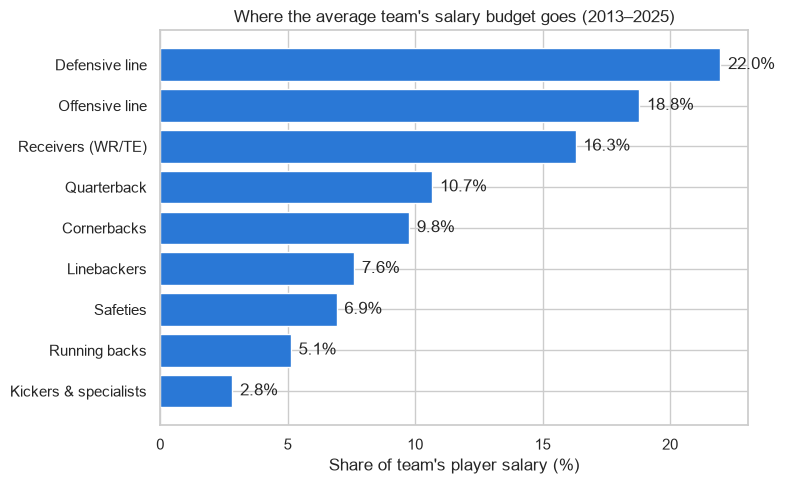

In [18]:
# Chart 1: average share per group, biggest first
average_share = share_long.groupby("group")["share_pct"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(average_share.index, average_share.values, color=BLUE)
ax.invert_yaxis()  # biggest bar on top
for position, value in enumerate(average_share.values):
    ax.text(value + 0.3, position, f"{value:.1f}%", va="center")
ax.set_title("Where the average team's salary budget goes (2013–2025)")
ax.set_xlabel("Share of team's player salary (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/average_share.png", dpi=150)
plt.show()

**Takeaway:** The two lines (defensive and offensive) take about 40% of the average budget between them. Running backs and kickers get the least.

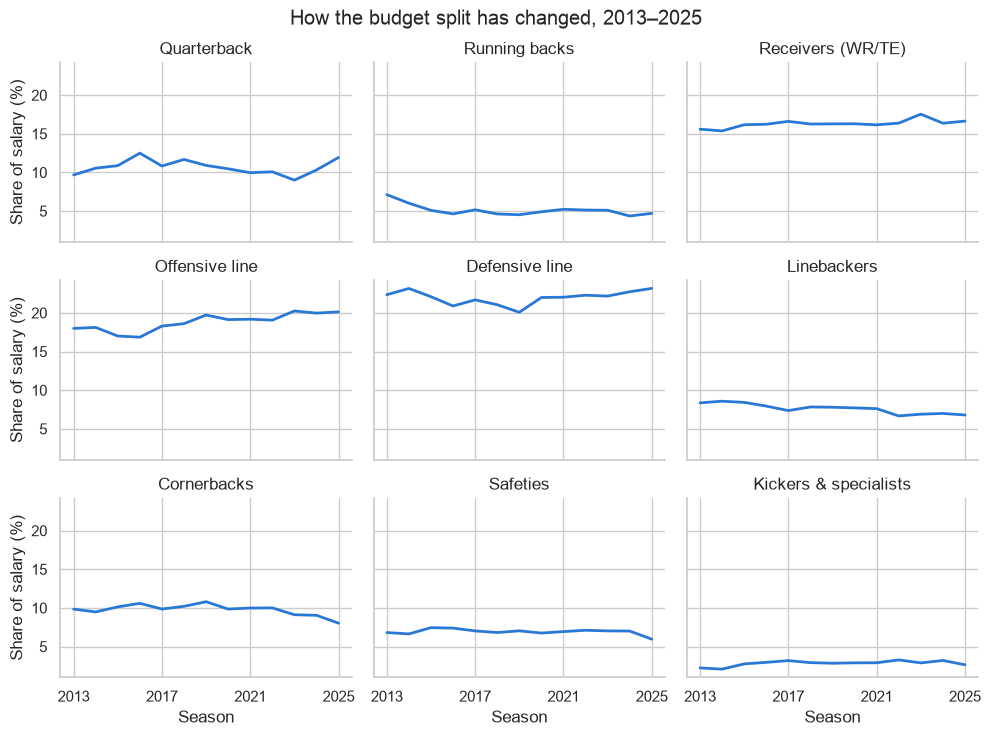

season,2013,2025,change
group,,,
Running backs,7.1,4.7,-2.4
Cornerbacks,9.8,8.0,-1.8
Linebackers,8.4,6.8,-1.6
Safeties,6.8,6.0,-0.9
Kickers & specialists,2.2,2.6,0.4
Defensive line,22.3,23.2,0.8
Receivers (WR/TE),15.6,16.6,1.0
Offensive line,18.0,20.1,2.1
Quarterback,9.7,11.9,2.3


In [19]:
# Chart 2: each group's average share by season, one small panel per group.
# All panels share the same y-axis so the sizes are comparable.
share_by_season = share_long.groupby(["group", "season"])["share_pct"].mean().reset_index()

grid = sns.relplot(
    data=share_by_season, x="season", y="share_pct",
    col="group", col_wrap=3, col_order=list(GROUP_LABELS.values()),
    kind="line", color=BLUE, linewidth=2, height=2.4, aspect=1.4,
)
grid.set_titles("{col_name}")
grid.set_axis_labels("Season", "Share of salary (%)")
grid.set(xticks=[2013, 2017, 2021, 2025])  # whole years, not 2012.5
grid.figure.suptitle("How the budget split has changed, 2013–2025", y=1.02)
grid.savefig("charts/share_over_time.png", dpi=150)
plt.show()

# The numbers behind the chart: first season vs last season
first_vs_last = share_by_season.pivot(index="group", columns="season", values="share_pct")[[2013, 2025]]
first_vs_last["change"] = first_vs_last[2025] - first_vs_last[2013]
first_vs_last.sort_values("change").round(1)

**Takeaway:** Since 2013, teams have moved money toward quarterbacks (+2.3 percentage points) and the offensive line (+2.1), and away from running backs (−2.4), cornerbacks (−1.8) and linebackers (−1.6). The shifts are gradual, a couple of points over 13 years.

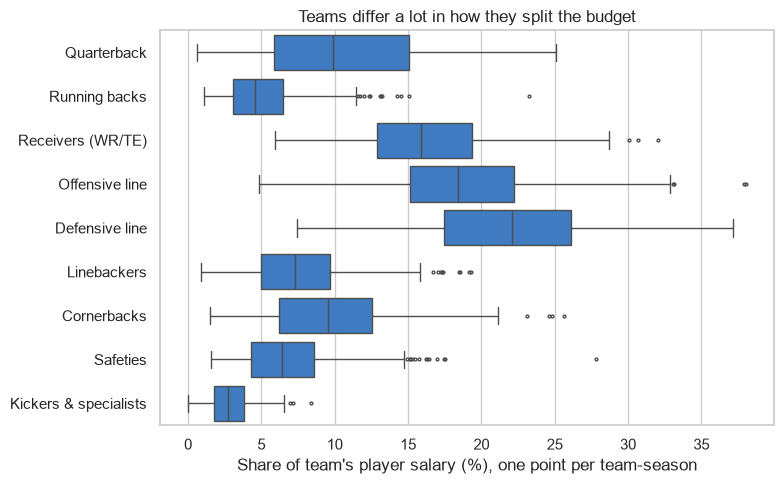

group
Defensive line           6.1
Quarterback              5.7
Offensive line           5.1
Receivers (WR/TE)        4.8
Cornerbacks              4.5
Linebackers              3.5
Safeties                 3.4
Running backs            2.8
Kickers & specialists    1.4
Name: share_pct, dtype: float64

In [20]:
# Chart 3: spread across teams. Each box covers the middle half of team-seasons.
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=share_long, x="share_pct", y="group", order=list(GROUP_LABELS.values()),
            color=BLUE, fliersize=2, ax=ax)
ax.set_title("Teams differ a lot in how they split the budget")
ax.set_xlabel("Share of team's player salary (%), one point per team-season")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/share_spread.png", dpi=150)
plt.show()

# Standard deviation in percentage points: how much teams typically differ per group
share_long.groupby("group")["share_pct"].std().sort_values(ascending=False).round(1)

**Takeaway:** Teams really do make different choices. The middle half of teams spends anywhere from about 6% to 15% on the quarterback. That variety is what lets us compare teams at all.

## §5 Correlations: which spending patterns go with winning?

A correlation measures how closely two things move together, from -1 to +1. A value of +0.2 between QB share and point differential would mean teams that spend more on QBs *tend* to outscore opponents by more, but only loosely.

*Summary:* We correlate every spending share and concentration measure with the two outcomes, and show the result as a color grid (a heatmap). Blue means "more of this goes with better results" and red means worse. Pale means almost no relationship. With 416 team-seasons, any correlation smaller than about ±0.10 could easily be chance.

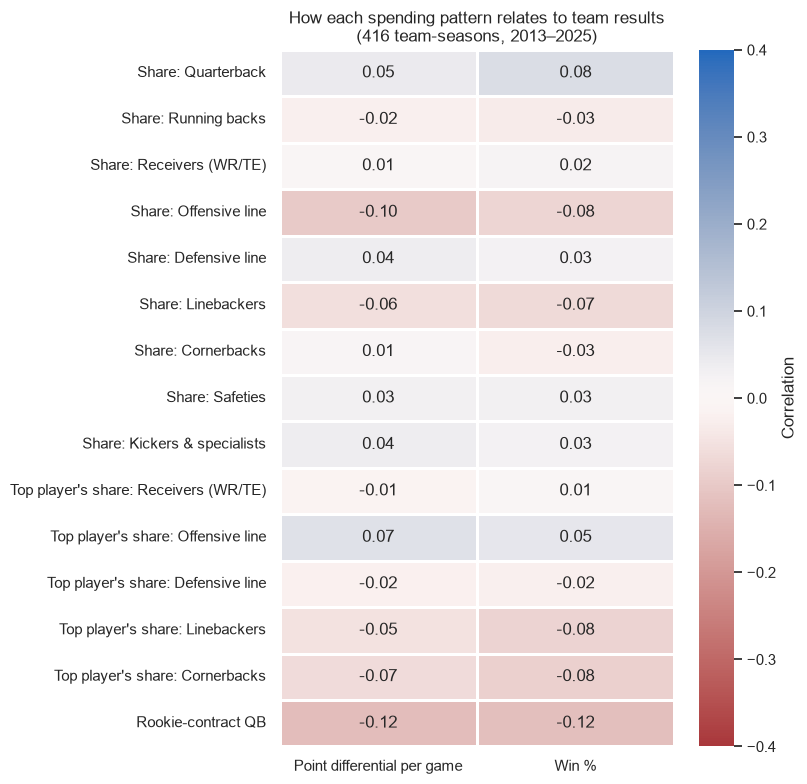

In [21]:
# Every measure we want to test, with a readable name for the chart
measure_labels = {}
for group, label in GROUP_LABELS.items():
    measure_labels[group + "_share"] = "Share: " + label
for group in MULTI_STARTER_GROUPS:
    measure_labels[group + "_top_share"] = "Top player's share: " + GROUP_LABELS[group]
measure_labels["rookie_qb"] = "Rookie-contract QB"

outcome_labels = {"point_diff_per_game": "Point differential per game", "win_pct": "Win %"}

# .corr() gives correlations between all columns; we keep measures (rows) vs outcomes (columns)
all_correlations = team_season[list(measure_labels) + list(outcome_labels)].corr()
correlations = all_correlations.loc[list(measure_labels), list(outcome_labels)]
correlations = correlations.rename(index=measure_labels, columns=outcome_labels)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag_r", center=0, vmin=-0.4, vmax=0.4,
            linewidths=2, linecolor="white", cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("How each spending pattern relates to team results\n(416 team-seasons, 2013–2025)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")  # "tight" keeps the color-bar label from being cut off
plt.show()

**Takeaway:** Every correlation falls between −0.12 and +0.08, so no single spending choice lines up strongly with results. The strongest is the rookie-QB flag (−0.12): teams with a QB on a rookie deal did slightly *worse*, likely because teams that just drafted a QB are often rebuilding. With 30 numbers on this chart, one or two crossing the ±0.10 "probably not chance" line is roughly what luck alone would produce.